In [1]:
# Basic packages always been used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error #MAE
from sklearn.metrics import mean_squared_error #MSE,RMSE
from sklearn.metrics import mean_absolute_percentage_error #MAPE

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
def naive_forecast(data):
  forecasts = []
  for i in range(len(data)):
    if i == 0:
      forecast = data[i]
    else:
      forecast = data[i-1]
    forecasts.append(forecast)
  return forecasts

In [31]:
#load data(sometimes need to use "/")
#df = pd.read_csv('D:/pythonData/python_demo_data/Titanic_demo_1.csv')
# Colab
data = pd.read_csv('/content/drive/MyDrive/USD-TWD(1).csv')
data

,Y,Y1
0,27.637,NaN
1,27.530,27.637
2,27.608,27.530
3,27.663,27.608
4,27.605,27.663
...,...,...
1145,31.464,31.550
1146,31.409,31.464
1147,31.435,31.409
1148,31.399,31.435


In [32]:
column_to_predict = 'Y'
data_to_predict = data[column_to_predict].values

In [33]:
forecasted_values = naive_forecast(data_to_predict)

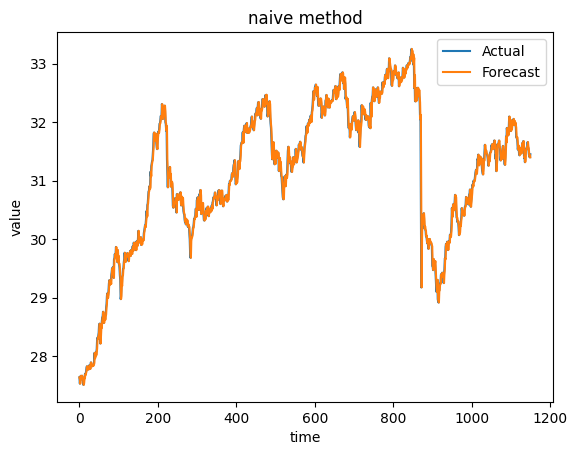

In [34]:
plt.plot(data_to_predict, label='Actual')
plt.plot(forecasted_values, label='Forecast')
plt.xlabel('time')
plt.ylabel('value')
plt.title('naive method')
plt.legend()
plt.show()

In [35]:
import csv
import numpy as np

data_float = []
with open('/content/drive/MyDrive/USD-TWD(1).csv') as file:
    reader = csv.reader(file)

    for row in reader:
        if len(row) == 2:
            try:
                value1 = float(row[0])
                value2 = float(row[1])
                data_float.append([value1, value2])
            except ValueError:
                continue

for row in data_float:
    print(row)

[27.53, 27.637]
[27.608, 27.53]
[27.663, 27.608]
[27.605, 27.663]
[27.656, 27.605]
[27.665, 27.656]
[27.647, 27.665]
[27.635, 27.647]
[27.54, 27.635]
[27.508, 27.54]
[27.54, 27.508]
[27.623, 27.54]
[27.623, 27.623]
[27.692, 27.623]
[27.681, 27.692]
[27.713, 27.681]
[27.741, 27.713]
[27.806, 27.741]
[27.827, 27.806]
[27.769, 27.827]
[27.785, 27.769]
[27.795, 27.785]
[27.773, 27.795]
[27.799, 27.773]
[27.844, 27.799]
[27.81, 27.844]
[27.782, 27.81]
[27.849, 27.782]
[27.893, 27.849]
[27.866, 27.893]
[27.844, 27.866]
[27.827, 27.844]
[27.835, 27.827]
[27.841, 27.835]
[27.837, 27.841]
[27.854, 27.837]
[27.884, 27.854]
[28.054, 27.884]
[27.964, 28.054]
[27.996, 27.964]
[28.065, 27.996]
[28.014, 28.065]
[28.06, 28.014]
[28.123, 28.06]
[28.284, 28.123]
[28.319, 28.284]
[28.295, 28.319]
[28.349, 28.295]
[28.402, 28.349]
[28.54, 28.402]
[28.555, 28.54]
[28.479, 28.555]
[28.216, 28.479]
[28.356, 28.216]
[28.497, 28.356]
[28.483, 28.497]
[28.595, 28.483]
[28.663, 28.595]
[28.669, 28.663]
[28.758, 

In [36]:
def MAE_calculate(actual, predict):
  n = len(actual)

  if n == 0:
      raise ValueError("actual and predict arrays should not be empty.")

  error_sum = sum(abs(actual[i] - predict[i]) for i in range(n))
  MAE = error_sum / n
  return MAE

def MSE_calculate(actual, predict):
  actual = np.array(actual)
  predict = np.array(predict)
  MSE = np.mean((actual - predict) ** 2)
  return MSE

def RMSE_calculate(actual, predict):
  actual = np.array(actual)
  predict = np.array(predict)
  squared_errors = (actual - predict) ** 2
  RMSE = np.sqrt(np.mean(squared_errors))
  return RMSE

def MAPE_calculate(actual, predict):
  actual = np.array(actual)
  predict = np.array(predict)
  ape = np.abs((actual - predict) / actual)
  ape[np.isinf(ape)] = 0.0  # 处理分母为0的情况
  ape[np.isnan(ape)] = 0.0  # 处理NaN值的情况
  MAPE = np.mean(ape) * 100
  return MAPE

def SMAPE_calculate(actual, predict):
  actual = np.array(actual)
  predict = np.array(predict)
  ape = np.abs(actual - predict) / ((np.abs(actual) + np.abs(predict)) / 2)
  ape[np.isinf(ape)] = 0.0  # 处理分母为0的情况
  ape[np.isnan(ape)] = 0.0  # 处理NaN值的情况
  SMAPE = np.mean(ape) * 100
  return SMAPE

def RAE_calculate(actual, predict):
  actual = np.array(actual)
  predict = np.array(predict)
  absolute_errors = np.abs(actual - predict)
  denominator = np.sum(np.abs(actual - np.mean(actual)))
  RAE = np.sum(absolute_errors/denominator)
  return RAE

def MRAE_calculate(actual, predict):
  actual = np.array(actual)
  predict = np.array(predict)
  n=len(actual)
  absolute_errors = np.abs(actual - predict)
  denominator = np.sum(np.abs(actual - np.mean(actual)))
  RAE = np.sum(absolute_errors/denominator)
  #MRAE = np.mean(RAE)
  MRAE = RAE / n
  return MRAE

def MdRAE_calculate(actual, predict, bench=None):
  if bench==None:
    bench=np.mean(actual)
    MdRAE=np.median([abs(a - p) / abs(a - bench) for a, p in zip(actual, predict)])
    return MdRAE,bench
  else:
    MdRAE=np.median([abs(a - p) / abs(a - b) for a, p, b in zip(actual, predict, bench)])
    return MdRAE

def RSE_calculate(actual, predict, Root=False):
  actual = np.array(actual)
  predict = np.array(predict)
  mse = np.mean((actual - predict)**2)
  denominator = np.var(actual)
  RSE=mse/denominator

  if Root==True:
      return np.sqrt(RSE)
  else:
      return RSE

In [37]:
column1 = [row[0] for row in data_float]
column2 = [row[1] for row in data_float]

In [38]:
import numpy as np

MAE=MAE_calculate(column1, column2)
rounded_MAE = np.round(MAE, 3)
MSE=MSE_calculate(column1, column2)
rounded_MSE = np.round(MSE, 3)
RMSE=RMSE_calculate(column1, column2)
rounded_RMSE = np.round(RMSE, 3)
MAPE=MAPE_calculate(column1, column2)
rounded_MAPE = np.round(MAPE, 3)
SMAPE=SMAPE_calculate(column1, column2)
rounded_SMAPE = np.round(SMAPE, 3)
RAE=RAE_calculate(column1, column2)
rounded_RAE = np.round(RAE, 3)
MRAE=MRAE_calculate(column1, column2)
RSE=RSE_calculate(column1, column2, Root=False)
rounded_RSE = np.round(RSE, 3)
RRSE=RSE_calculate(column1, column2, Root=True)
rounded_RRSE = np.round(RRSE, 3)

print('MAE:', rounded_MAE)
print('MSE:', rounded_MSE)
print('RMSE:', rounded_RMSE)
print('MAPE:', rounded_MAPE,'%')
print('SMAPE:', rounded_SMAPE,'%')
print('RAE:', rounded_RAE)
print('MRAE:', MRAE)
result = MdRAE_calculate(column1, column2)
if isinstance(result, tuple):
    MdRAE = result[0]
    bench = result[1]
    print('MdRAE:', round(MdRAE, 3), 'bench:', round(bench, 3))
else:
    MdRAE = result
    print('MdRAE:', round(MdRAE, 3))
print('RSE:', rounded_RSE)
print('RRSE:', rounded_RRSE)

MAE: 0.079
MSE: 0.014
RMSE: 0.12
MAPE: 0.254 %
SMAPE: 0.253 %
RAE: 0.077
MRAE: 6.739719274957161e-05
MdRAE: 0.073 bench: 31.109
RSE: 0.009
RRSE: 0.096
